In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# -----ACTION: To Merge the listed datasets below------
#Copies of the raw data has been saved to a folder
#olist_orders_dataset
#olist_customers_dataset
#olist_order_items_dataset
#olist_products_dataset
#product_category_name_translation
#olist_sellers_dataset
#olist_order_payments_dataset
#olist_order_reviews_dataset
#olist_geolocation_dataset
#Load the datasets below

# -----Load the listed datasets------
orders = pd.read_csv("olist_orders_dataset.csv")
#To ensure the zip code is read as a string and no leading zeros is lost
customers = pd.read_csv(
    "olist_customers_dataset.csv",
    dtype={"customer_zip_code_prefix": "string"}
)

order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
product_category_translation = pd.read_csv("product_category_name_translation.csv")
#To ensure the zip code is read as a string and no leading zeros is lost
sellers = pd.read_csv(
    "olist_sellers_dataset.csv",
    dtype={
        "seller_zip_code_prefix": "string"
    }
)

order_payments = pd.read_csv("olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
#To ensure the zip code is read as a string and no leading zeros is lost
geolocation = pd.read_csv(
    "olist_geolocation_dataset.csv",
    dtype={"geolocation_zip_code_prefix": "string"}
)

print("All 9 dataset has been loaded successfully")


In [ ]:
#-----Optimize the geolocation data-------
geo_reduced = (
    geolocation
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean",
        "geolocation_city": "first",
        "geolocation_state": "first"
    })
)

print("Original geolocation shape:", geolocation.shape)
print("Reduced geolocation shape:", geo_reduced.shape)
geo_reduced.head()


In [75]:
#------Begin Merging the data-----
#Merge Customers and Order Data - Start with the order data becuase its the fact table
Data = orders.merge(customers,on='customer_id',how='left')
#Merge the Order items data set to the Data 
#Confirm merge
Data = Data.merge(
    order_items,
    on="order_id",
    how="left"
)

#Merge the products data set to the Data 
#Confirm merge
Data = Data.merge(
    products,
    on="product_id",
    how="left"
)

#Merge the product_category_translation data set to the Data 
#Confirm merge
Data = Data.merge(    
 product_category_translation,
    on="product_category_name",
    how="left"
)

#Merge the sellers data set to the Data 
#Confirm merge
Data = Data.merge(    
    sellers,
    on="seller_id",
    how="left"
)

#Merge the payments data set to the Data 
#Confirm merge
Data = Data.merge(    
     order_payments,
    on="order_id",
    how="left"
)

#Merge the reviews data set to the Data. We only need the review score and the order_id to avoid noise
#Confirm merge
Data = Data.merge(    
    order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

#Merge the geolocation data set to the Data.
#Confirm merge
Data = Data.merge(    
    geo_reduced,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)
print("Merged successfully")
print("Shape:", Data.shape)
Data.head()
Data.columns

Merged successfully
Shape: (119143, 40)


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_score',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

In [76]:
Data.describe()
Data.info()
Data.shape
Data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  string 
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_score',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

In [78]:
#My core identifiers do not have any nulls
#Convert date columns to datetime
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for col in date_cols:
    Data[col] = pd.to_datetime(Data[col], errors="coerce")
#check again
Data.dtypes


order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix         string[python]
customer_city                            object
customer_state                           object
order_item_id                           float64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              

In [79]:
#Fix data types of geolocation_zip_code_prefix, customer_zip_code_prefix,order item id
Data["order_item_id"] = Data["order_item_id"].astype("string")
#run check again
Data.dtypes


order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix         string[python]
customer_city                            object
customer_state                           object
order_item_id                    string[python]
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              

In [80]:
#Now lets go over to data cleaning - missing value check
Data.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    3421
product_category_name_english    2567
product_description_lenght       2542
product_photos_qty               2542
product_name_lenght              2542
product_category_name            2542
order_delivered_carrier_date     2086
review_score                      997
product_width_cm                  853
product_length_cm                 853
product_weight_g                  853
product_height_cm                 853
seller_zip_code_prefix            833
product_id                        833
seller_id                         833
shipping_limit_date               833
price                             833
freight_value                     833
seller_city                       833
seller_state                      833
order_item_id                     833
geolocation_zip_code_prefix       322
geolocation_lat                   322
geolocation_lng                   322
geolocation_city                  322
geolocation_state                 322
order_approv

In [81]:
Data.duplicated().sum()

np.int64(421)

In [82]:
#check for duplicates
duplicates = Data[Data.duplicated(keep=False)]
duplicates.head(10)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_score,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
480,ac7a92560a9e99f0a0ab4988102f491b,6abf781c5304890987047e9aa239caa8,delivered,2018-03-04 15:58:09,2018-03-04 16:10:35,2018-03-06 17:14:59,2018-03-22 23:44:33,2018-03-23,a176838867d89ed62981cdf02b7ca3e1,86040,...,1.0,credit_card,6.0,107.87,1.0,86040,-23.338994,-51.136186,londrina,PR
481,ac7a92560a9e99f0a0ab4988102f491b,6abf781c5304890987047e9aa239caa8,delivered,2018-03-04 15:58:09,2018-03-04 16:10:35,2018-03-06 17:14:59,2018-03-22 23:44:33,2018-03-23,a176838867d89ed62981cdf02b7ca3e1,86040,...,1.0,credit_card,6.0,107.87,1.0,86040,-23.338994,-51.136186,londrina,PR
659,7845a2492ab1b4f2cf3d56c7b8da1446,386e96046ce0e77e5c9a9a4e818da93c,delivered,2018-01-18 12:35:45,2018-01-18 12:56:40,2018-01-18 23:42:44,2018-01-23 21:51:48,2018-02-09,1175e95fb47ddff9de6b2b06188f7e0d,81560,...,1.0,debit_card,1.0,44.09,5.0,81560,-25.486784,-49.217558,curitiba,PR
660,7845a2492ab1b4f2cf3d56c7b8da1446,386e96046ce0e77e5c9a9a4e818da93c,delivered,2018-01-18 12:35:45,2018-01-18 12:56:40,2018-01-18 23:42:44,2018-01-23 21:51:48,2018-02-09,1175e95fb47ddff9de6b2b06188f7e0d,81560,...,1.0,debit_card,1.0,44.09,5.0,81560,-25.486784,-49.217558,curitiba,PR
737,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22,c4ebedb09beb89cc0314c5c0c33f8053,09961,...,1.0,credit_card,4.0,96.01,1.0,09961,-23.702465,-46.596052,diadema,SP
738,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22,c4ebedb09beb89cc0314c5c0c33f8053,09961,...,1.0,credit_card,4.0,96.01,1.0,09961,-23.702465,-46.596052,diadema,SP
799,acbe07f22f29ad7e5a78f30008cc6ec7,b4afeb58ac51bc903c5362286c6a5cfe,delivered,2017-11-18 14:33:04,2017-11-18 19:06:16,2017-11-27 18:34:31,2017-11-29 17:58:43,2017-12-05,6457b2cb5462c1217e8e6d36b0ff39d2,05842,...,1.0,credit_card,2.0,124.12,5.0,05842,-23.650278,-46.744205,sao paulo,SP
800,acbe07f22f29ad7e5a78f30008cc6ec7,b4afeb58ac51bc903c5362286c6a5cfe,delivered,2017-11-18 14:33:04,2017-11-18 19:06:16,2017-11-27 18:34:31,2017-11-29 17:58:43,2017-12-05,6457b2cb5462c1217e8e6d36b0ff39d2,05842,...,1.0,credit_card,2.0,124.12,5.0,05842,-23.650278,-46.744205,sao paulo,SP
801,acbe07f22f29ad7e5a78f30008cc6ec7,b4afeb58ac51bc903c5362286c6a5cfe,delivered,2017-11-18 14:33:04,2017-11-18 19:06:16,2017-11-27 18:34:31,2017-11-29 17:58:43,2017-12-05,6457b2cb5462c1217e8e6d36b0ff39d2,05842,...,1.0,credit_card,2.0,124.12,5.0,05842,-23.650278,-46.744205,sao paulo,SP
802,acbe07f22f29ad7e5a78f30008cc6ec7,b4afeb58ac51bc903c5362286c6a5cfe,delivered,2017-11-18 14:33:04,2017-11-18 19:06:16,2017-11-27 18:34:31,2017-11-29 17:58:43,2017-12-05,6457b2cb5462c1217e8e6d36b0ff39d2,05842,...,1.0,credit_card,2.0,124.12,5.0,05842,-23.650278,-46.744205,sao paulo,SP


In [83]:
#Remove duplicates as I have confirmed that they are exactly the same and adds no business value, drop them
Data = Data.drop_duplicates()

In [86]:
#Confirm drop
Data.duplicated().sum()

np.int64(0)

In [87]:
#Lets save a clean file
Data.to_csv('Data_cleaned.csv', index=False)
print('Data has been saved using to_csv.')

Data has been saved using to_csv.


In [89]:
#Install the Brazilian holiday data 
import holidays

In [90]:
# Generate Brazil National Holidays for the Olist holiday period
# Olist data primarily spans 2016, 2017, and 2018
holidays = holidays.Brazil(years=[2016, 2017, 2018])

In [95]:

#  Convert the dictionary to a DataFrame
holiday_list = []
for date, name in sorted(holidays.items()):
    holiday_list.append({
        'holiday_date': date,
        'holiday_name': name
    })

holiday_df = pd.DataFrame(holiday_list)

# Convert date column to datetime objects to match your merged dataset
holiday_df['holiday_date'] = pd.to_datetime(holiday_df['holiday_date'])

# Save file
holiday_df.to_csv('brazilian_holidays_2016_2018.csv', index=False)

print("Holiday dataset created successfully!")
print(holiday_df.head())

Holiday dataset created successfully!
  holiday_date                holiday_name
0   2016-01-01  Confraternização Universal
1   2016-03-25           Sexta-feira Santa
2   2016-04-21                  Tiradentes
3   2016-05-01          Dia do Trabalhador
4   2016-09-07     Independência do Brasil


In [96]:

#  Extract only the Date (without time) to match the holiday table
Data['order_purchase_date_only'] = Data['order_purchase_timestamp'].dt.normalize()

# Perform the merge
Data = Data.merge( 
    holiday_df, 
    left_on='order_purchase_date_only', 
    right_on='holiday_date', 
    how='left'
)

#  Create a binary 'is_holiday' flag and clean up
Data['is_holiday'] =Data['holiday_name'].notna()
Data['holiday_name'] = Data['holiday_name'].fillna('Not a Holiday')

# Drop the extra merge column
Data.drop(columns=['holiday_date'], inplace=True)

print("Merge complete! You can now analyze sales performance on holidays.")

Merge complete! You can now analyze sales performance on holidays.


In [97]:
Data.describe()
Data.info()
Data.shape
Data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118722 entries, 0 to 118721
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118722 non-null  object        
 1   customer_id                    118722 non-null  object        
 2   order_status                   118722 non-null  object        
 3   order_purchase_timestamp       118722 non-null  datetime64[ns]
 4   order_approved_at              118546 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116640 non-null  datetime64[ns]
 6   order_delivered_customer_date  115311 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118722 non-null  datetime64[ns]
 8   customer_unique_id             118722 non-null  object        
 9   customer_zip_code_prefix       118722 non-null  string        
 10  customer_city                  118722 non-null  object        
 11  

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_score',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state', 'order_purchase_date_only',
       'holiday_name', 'is_ho

In [101]:
# ---------EXPLORATORY DATA ANALYSIS-----------------#

#BUSINESS QUESTIONS
#1. Which customers made the most purchases (top 5)
# We filter for 'delivered' status and ensure the delivery date is not missing
Delivered_orders = Data[
    (Data['order_status'] == 'delivered') & 
    (Data['order_delivered_customer_date'].notna())
].copy()

# We use customer_unique_id to track the same person across multiple orders
top_5_customers = Delivered_orders .groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False).head(5)

print("Top 5 Customers by Successful Delivered Orders: ")
print(top_5_customers)

Top 5 Customers by Successful Delivered Orders: 
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    15
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
Name: order_id, dtype: int64


In [102]:
# --- 2. Sellers with the most sales. Lets do Top 5 sellers ---
top_5_sellers = Delivered_orders.groupby('seller_id')['order_id'].nunique().sort_values(ascending=False).head(5)

print("\n Top 5 Sellers by Successful Sales:")
print(top_5_sellers)


 Top 5 Sellers by Successful Sales:
seller_id
6560211a19b47992c3666cc44a7e94c0    1819
4a3ca9315b744ce9f8e9374361493884    1772
cc419e0650a3c5ba77189a1882b7556a    1651
1f50f920176fa81dab994f9023523100    1399
da8622b14eb17ae2831f4ac5b9dab84a    1311
Name: order_id, dtype: int64


In [119]:
# --- 3. How many orders are made per month?

# 1. Ensure you have a 'Year' column and 'Month Name' column
# We use .dt.year and .dt.strftime('%B') to extract these
Delivered_orders['year'] = Delivered_orders['order_purchase_timestamp'].dt.year
Delivered_orders['month_only'] = Delivered_orders['order_purchase_timestamp'].dt.strftime('%B')

# 2. Define the correct month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 3. Create a Pivot Table to separate orders by Year and Month
# This counts unique orders (nunique) for every month of every year
monthly_orders_per_year = Delivered_orders.pivot_table(
    index='month_only', 
    columns='year', 
    values='order_id', 
    aggfunc='nunique'
)

# 4. Reindex to ensure the months are in calendar order (Jan-Dec)
monthly_orders_per_year = monthly_orders_per_year.reindex(month_order)

# 5. Fill any months with no data with 0 and convert to integers for a cleaner look
monthly_orders_per_year = monthly_orders_per_year.fillna(0).astype(int)

print("Monthly Orders Separated by Year:")
print(monthly_orders_per_year)



--- Monthly Orders Separated by Year ---
year        2016  2017  2018
month_only                  
January        0   750  7069
February       0  1653  6555
March          0  2546  7003
April          0  2303  6798
May            0  3545  6749
June           0  3135  6096
July           0  3872  6156
August         0  4193  6351
September      1  4150     0
October      265  4478     0
November       0  7288     0
December       1  5513     0


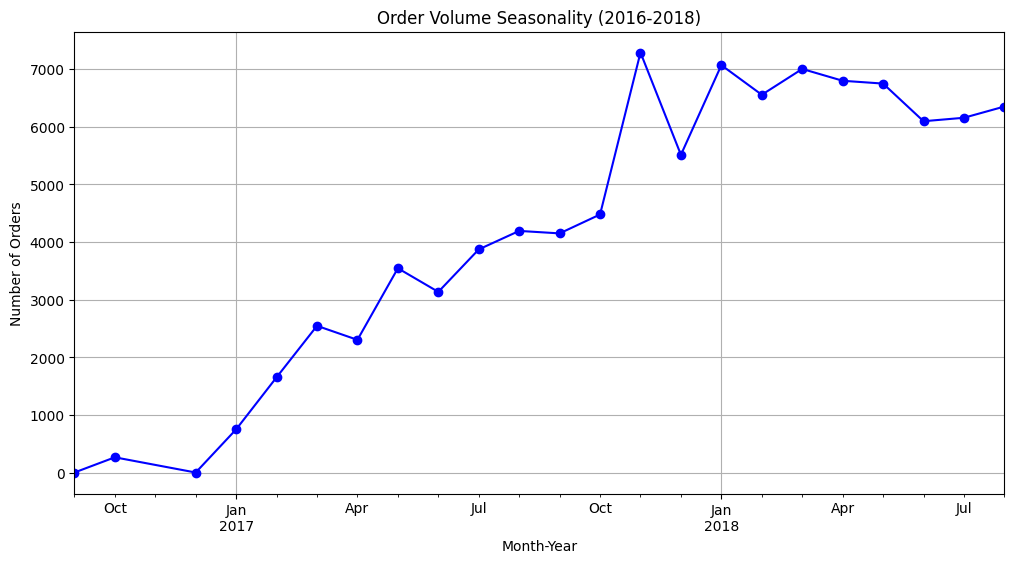

Average Orders per Day:
is_holiday
False    158.321667
True     123.083333
Name: order_id, dtype: float64


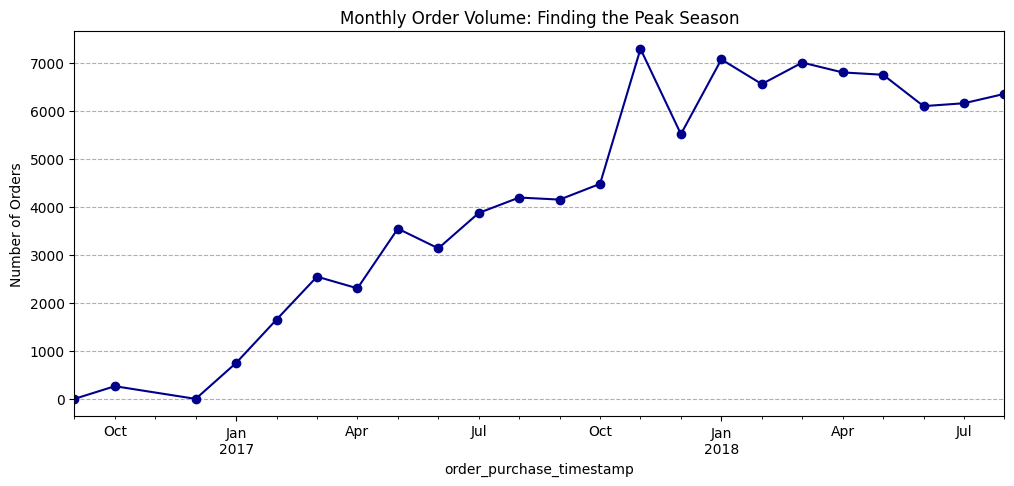

In [116]:
# 4. Is there any seasonality in order volume?

import matplotlib.pyplot as plt

# 1. Group by month/year to see the timeline
monthly_trends =Delivered_orders.groupby(Delivered_orders['order_purchase_timestamp'].dt.to_period('M'))['order_id'].nunique()

# 2. Plotting the results to visually spot seasonality
plt.figure(figsize=(12,6))
monthly_trends.plot(kind='line', marker='o', color='b')
plt.title('Order Volume Seasonality (2016-2018)')
plt.ylabel('Number of Orders')
plt.xlabel('Month-Year')
plt.grid(True)
plt.show()

# Calculate average orders per day for Holidays vs Regular Days
daily_orders = Delivered_orders.groupby(['order_purchase_date_only', 'is_holiday'])['order_id'].nunique().reset_index()
seasonality_check = daily_orders.groupby('is_holiday')['order_id'].mean()

print("Average Orders per Day:")
print(seasonality_check)

"""
Yes, there is significant seasonality in the order volume
The analysis of delivered orders from 2016–2018 reveals that Olist's volume is driven by Commercial Events rather than Statutory Holidays.

The Black Friday Powerhouse: November 2017 stands as the definitive annual peak, showing a 62% surge compared to October. This confirms that the Brazilian market is highly responsive to major discount events.

The "Holiday Paradox": Contrary to expectations, daily order volume drops by 22% on national holidays (123 vs. 158 orders). This suggests that consumers prioritize offline activities and travel during official days off, leading to a temporary e-commerce lull.

The Year-End "V" Pattern: The data shows high volatility between Q4 and Q1, characterized by a massive November spike, a deep December dip, and a sharp "New Year" recovery in January.

Consistent Platform Growth: Beyond seasonal fluctuations, a strong growth trend is evident, with 2018 monthly volumes consistently outperforming 2017, indicating successful platform scaling.

Strategic Recommendation:
Marketing and logistics efforts should be maximized during the "lead-up" to major dates and concentrated heavily on Commercial Windows (like Black Friday) rather than the actual public holidays themselves.
"""

In [173]:
# 5. Average time between order purchase and delivery
#  Calculate the difference in days
# We subtract the purchase time from the delivery time
Delivered_orders['delivery_time_days'] = (Delivered_orders['order_delivered_customer_date'] - Delivered_orders['order_purchase_timestamp']).dt.days

# Calculate the average
average_delivery_time = Delivered_orders['delivery_time_days'].mean()

print(f"The average time from purchase to delivery is: {average_delivery_time:.2f} days")

The average time from purchase to delivery is: 12.02 days


In [169]:
#6. What is the average shipping delay (actual - estimated delivery)
#  Calculate the delay in days
# Positive result = Late | Negative result = Early
Delivered_orders['delivery_delay'] = (Delivered_orders['order_delivered_customer_date'] - Delivered_orders['order_estimated_delivery_date']).dt.days

# Calculate the average
avg_delay = Delivered_orders['delivery_delay'].mean()

print(f"The average shipping delay is: {avg_delay:.2f} days")


The average shipping delay is: -12.04 days


In [168]:
# 7. How long does each step in the order process take 

# Step 1: Purchase → Approval (Payment Confirmation)
Delivered_orders['step1_approval_time'] = (
    Delivered_orders['order_approved_at'] - Delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

#Step 2: Approval → Carrier (Seller Processing Time)
Delivered_orders['step2_processing_time'] = (
    Delivered_orders['order_delivered_carrier_date'] - Delivered_orders['order_approved_at']
).dt.total_seconds() / 86400

# Step 3: Carrier → Customer (Logistics/Transit Time)
Delivered_orders['step3_transit_time'] = (
    Delivered_orders['order_delivered_customer_date'] - Delivered_orders['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# Summary Statistics
print("--- Average Time per Process Step (in Days) ---")
print(f"1. Purchase to Approval: {Delivered_orders['step1_approval_time'].mean():.2f} days")
print(f"2. Approval to Carrier:  {Delivered_orders['step2_processing_time'].mean():.2f} days")
print(f"3. Carrier to Delivery:  {Delivered_orders['step3_transit_time'].mean():.2f} days")


--- Average Time per Process Step (in Days) ---
1. Purchase to Approval: 0.43 days
2. Approval to Carrier:  2.85 days
3. Carrier to Delivery:  9.20 days


In [172]:
#8. Analyze one-time and returning customers
# 1. Count orders per unique customer
# We group by unique_id and count unique order_ids
customer_counts = Delivered_orders.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_counts.rename(columns={'order_id': 'order_count'}, inplace=True)

# Create the 'Customer Type' logic
# 1 order = One-time, >1 order = Returning
customer_counts['customer_type'] = customer_counts['order_count'].apply(
    lambda x: 'Returning' if x > 1 else 'One-time'
)
# Calculate the Statistics
type_summary = customer_counts['customer_type'].value_counts()
percentage_summary = customer_counts['customer_type'].value_counts(normalize=True) * 100

# Print the results for your report
print("Customer Retention Analysis:")
print(f"One-time Customers:  {type_summary['One-time']} ({percentage_summary['One-time']:.2f}%)")
print(f"Returning Customers: {type_summary['Returning']} ({percentage_summary['Returning']:.2f}%)")

# Let us Identify the 'Super Fans' (Top 5 returning customers)
print("\nTop 5 Most Loyal Customers :")
print(customer_counts.sort_values(by='order_count', ascending=False).head(5))


Customer Retention Analysis:
One-time Customers:  90537 (97.00%)
Returning Customers: 2800 (3.00%)

Top 5 Most Loyal Customers :
                     customer_unique_id  order_count customer_type
51421  8d50f5eadf50201ccdcedfb9e2ac8455           15     Returning
22774  3e43e6105506432c953e165fb2acf44c            9     Returning
10058  1b6c7548a2a1f9037c1fd3ddfed95f33            7     Returning
36700  6469f99c1f9dfae7733b25662e7f1782            7     Returning
73906  ca77025e7201e3b30c44b472ff346268            7     Returning


In [135]:
# 9. Average product rating (review_score) by customer
# Calculate the average score per unique customer
# This accounts for customers who have made multiple purchases
customer_ratings = Delivered_orders.groupby('customer_unique_id')['review_score'].mean().reset_index()

#  Get the overall average of all customers
overall_avg_rating = customer_ratings['review_score'].mean()

# See the distribution (how many 5s, 4s, etc.)
rating_counts = Delivered_orders['review_score'].value_counts().sort_index(ascending=False)

print(f"--- Customer Sentiment Analysis ---")
print(f"The average rating across all customers is: {overall_avg_rating:.2f} / 5.00")
print("\n Breakdown of Scores :")
print(rating_counts)

--- Customer Sentiment Analysis ---
The average rating across all customers is: 4.15 / 5.00

 Breakdown of Scores :
review_score
5.0    65749
4.0    22102
3.0     9628
2.0     3896
1.0    13068
Name: count, dtype: int64


In [139]:
# 10. What are the most popular products

top_categories = Delivered_orders['product_category_name_english'].value_counts().head(10)

print("\n--- Top 10 Product Categories ---")
print(top_categories)



--- Top 10 Product Categories ---
product_category_name_english
bed_bath_table           11724
health_beauty             9774
sports_leisure            8745
furniture_decor           8608
computers_accessories     7929
housewares                7180
watches_gifts             6071
telephony                 4603
garden_tools              4474
auto                      4288
Name: count, dtype: int64


In [141]:
# 11. What is the distribution of payment types
#Count the occurrences of each payment type
payment_distribution = Delivered_orders['payment_type'].value_counts().reset_index()
payment_distribution.columns = ['payment_type', 'transaction_count']

#  Calculate the percentage for each type
payment_distribution['percentage'] = (
    payment_distribution['transaction_count'] / payment_distribution['transaction_count'].sum()
) * 100

print("Payment Type Distribution:")
print(payment_distribution)

Payment Type Distribution:
  payment_type  transaction_count  percentage
0  credit_card              85077   73.786871
1       boleto              22418   19.443023
2      voucher               6152    5.335600
3   debit_card               1654    1.434506


Highest Average Payment Value by Method:
  Payment Type   Avg Value
0  credit_card  178.918129
1       boleto  176.354208
2   debit_card  148.980212
3      voucher   64.806975


C:\Users\oogunjemilua\AppData\Local\Temp\ipykernel_18420\1352653445.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_payment_val, x='Payment Type', y='Avg Value', palette='Blues_d')


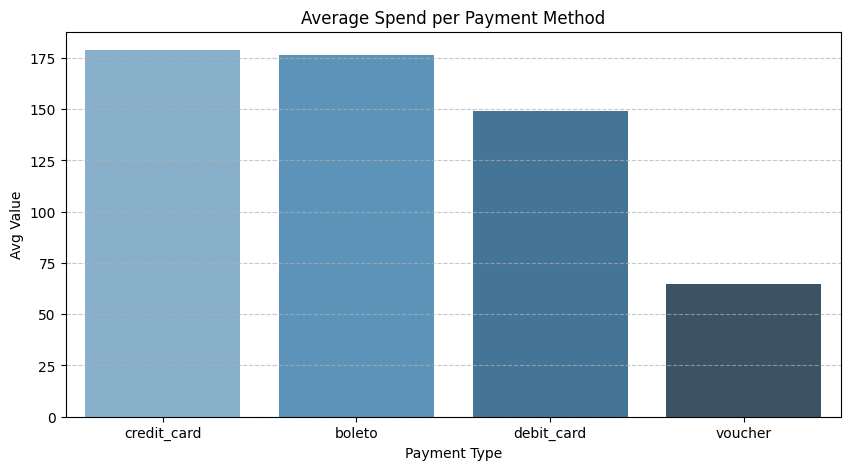

In [144]:
#12. Which payment type has the highest average payment value

# Calculate Average Payment Value per Payment Type
avg_payment_val = Delivered_orders.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False).reset_index()

# Rename columns for clarity
avg_payment_val.columns = ['Payment Type', 'Avg Value']

# Print the results
print("Highest Average Payment Value by Method:")
print(avg_payment_val)

#Quick Visualization to see the gap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_payment_val, x='Payment Type', y='Avg Value', palette='Blues_d')
plt.title('Average Spend per Payment Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [145]:
# 13.  How many customers pay in a single installment vs multiple
#Create a function to categorize the installments
# 1 installment = 'Single Installment'
# > 1 installment = 'Multiple Installments'
Delivered_orders['installment_type'] = Delivered_orders['payment_installments'].apply(
    lambda x: 'Single Installment' if x == 1 else 'Multiple Installments'
)

# Count the number of transactions for each type
installment_counts = Delivered_orders['installment_type'].value_counts()

# Calculate percentages
installment_percents = Delivered_orders['installment_type'].value_counts(normalize=True) * 100

print("--- Single vs. Multiple Installments ---")
print(f"Single Installment:    {installment_counts['Single Installment']} ({installment_percents['Single Installment']:.2f}%)")
print(f"Multiple Installments: {installment_counts['Multiple Installments']} ({installment_percents['Multiple Installments']:.2f}%)")

#  See the most common number of installments
print("\n--- Top 5 Installment Counts ---")
print(Delivered_orders['payment_installments'].value_counts().head(5))

--- Single vs. Multiple Installments ---
Single Installment:    57501 (49.87%)
Multiple Installments: 57803 (50.13%)

--- Top 5 Installment Counts ---
payment_installments
1.0     57501
2.0     13451
3.0     11511
4.0      7822
10.0     6730
Name: count, dtype: int64


In [146]:
#14 .  What product categories have the highest review scores
# Group by category and calculate both the Average Rating and the Count of orders
category_reviews = Delivered_orders.groupby('product_category_name').agg({
    'review_score': 'mean',
    'order_id': 'count'
}).reset_index()

# Rename columns for clarity
category_reviews.columns = ['product_category', 'avg_review_score', 'order_count']

# Filter for reliability (Only categories with more than 100 orders)
reliable_categories = category_reviews[category_reviews['order_count'] > 100]

# Get the Top 10 highest rated categories
top_rated = reliable_categories.sort_values(by='avg_review_score', ascending=False).head(10)

print(" Top 10 Highest Rated Product Categories (>100 orders):")
print(top_rated)


 Top 10 Highest Rated Product Categories (>100 orders):
                      product_category  avg_review_score  order_count
48              livros_interesse_geral          4.501838          548
22  construcao_ferramentas_ferramentas          4.415842          105
49                     livros_tecnicos          4.396226          266
2                    alimentos_bebidas          4.385714          280
50                    malas_acessorios          4.330420         1148
1                            alimentos          4.272366          515
34                    fashion_calcados          4.269663          272
59                           papelaria          4.237162         2566
31                     eletroportateis          4.229290          681
0            agro_industria_e_comercio          4.227642          246


In [150]:
#15. Which products have the longest delivery times
# Calculate delivery time in days
Delivered_orders['delivery_time_days'] = (
    Delivered_orders['order_delivered_customer_date'] - Delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

#  Group by category and find the average
# Filtering for categories with >100 orders to avoid outliers
long_del = Delivered_orders.groupby('product_category_name').agg({
    'delivery_time_days': 'mean',
    'order_id': 'count'
}).reset_index()

long_del = long_del[long_del['order_id'] > 100]
long_del =long_del.sort_values(by='delivery_time_days', ascending=False).head(10)

print(" Top 10 Categories with Longest Delivery Times :")
print(long_del)

 Top 10 Categories with Longest Delivery Times :
             product_category_name  delivery_time_days  order_id
55               moveis_escritorio           20.961558      1761
6                 artigos_de_natal           15.725018       152
34                fashion_calcados           15.308392       272
57                     moveis_sala           13.997901       520
40              ferramentas_jardim           13.745240      4474
29              eletrodomesticos_2           13.712410       261
20                  consoles_games           13.591597      1140
39  fashion_underwear_e_moda_praia           13.543288       140
14                   casa_conforto           13.446630       472
61                             pcs           13.435387       216


In [154]:
#16. What is the average product price and freight cost per category
# Group by English Category to get the averages
# We use .agg to calculate mean price, mean freight, and order count simultaneously
cost_per_cat = Delivered_orders.groupby('product_category_name_english').agg({
    'price': 'mean',
    'freight_value': 'mean',
    'order_id': 'count'
}).reset_index()

# Rename columns for a professional look
cost_per_cat.columns = ['Category', 'Avg_Price', 'Avg_Freight', 'Order_Count']

#  Filter for reliability (Categories with > 100 orders)
# This removes "noise" from categories with very few transactions
cost_per_cat =cost_per_cat[cost_per_cat['Order_Count'] > 100]

# Calculate the 'Freight Ratio' 
# This shows what percentage of the total product cost is just shipping
cost_per_cat['Freight_Ratio_Percent'] = (cost_per_cat['Avg_Freight'] / cost_per_cat['Avg_Price']) * 100

#  Display the Top 10 by Price (The "Premium" Categories)
print("--- Top 10 Categories by Average Price ---")
print(cost_per_cat.sort_values(by='Avg_Price', ascending=False).head(10))

#  Display the Top 10 by Freight (The "Bulkiest" Categories)
print("\n--- Top 10 Categories by Average Freight Cost ---")
print(cost_per_cat.sort_values(by='Avg_Freight', ascending=False).head(10))

--- Top 10 Categories by Average Price ---
                      Category    Avg_Price  Avg_Freight  Order_Count  \
14                   computers  1104.317685    48.111667          216   
45           home_appliances_2   451.729962    46.098314          261   
0   agro_industry_and_commerce   332.835691    27.481382          246   
56         musical_instruments   296.108561    27.382442          688   
63            small_appliances   283.744787    23.671175          681   
34             fixed_telephony   214.687663    17.640383          261   
19   construction_tools_safety   213.188824    20.272032          187   
70               watches_gifts   199.993817    16.795625         6071   
1             air_conditioning   184.561156    22.551905          294   
38           furniture_bedroom   176.039496    43.692269          119   

    Freight_Ratio_Percent  
14               4.356687  
45              10.204839  
0                8.256741  
56               9.247433  
63           

In [155]:
#17 Which product categories have the highest return or low ratings

#Group by English Category and calculate Mean Rating and Order Count
low_rating_categories = Delivered_orders.groupby('product_category_name_english').agg({
    'review_score': 'mean',
    'order_id': 'count'
}).reset_index()

# Filter for reliability (Only categories with > 100 orders)
low_rating_categories = low_rating_categories[low_rating_categories['order_id'] > 100]

# Sort by Review Score (Ascending=True to see the lowest scores first)
worst_rated = low_rating_categories.sort_values(by='review_score', ascending=True).head(10)

print("--- Top 10 Categories with the Lowest Customer Ratings ---")
print(worst_rated[['product_category_name_english', 'review_score', 'order_id']])


--- Top 10 Categories with the Lowest Customer Ratings ---
   product_category_name_english  review_score  order_id
57              office_furniture      3.551546      1761
30         fashion_male_clothing      3.649635       138
34               fixed_telephony      3.755814       261
4                          audio      3.845333       379
7                 bed_bath_table      3.914705     11724
47                  home_confort      3.925532       472
38             furniture_bedroom      3.941176       119
40         furniture_living_room      3.943137       520
39               furniture_decor      3.958348      8608
48             home_construction      3.971061       626


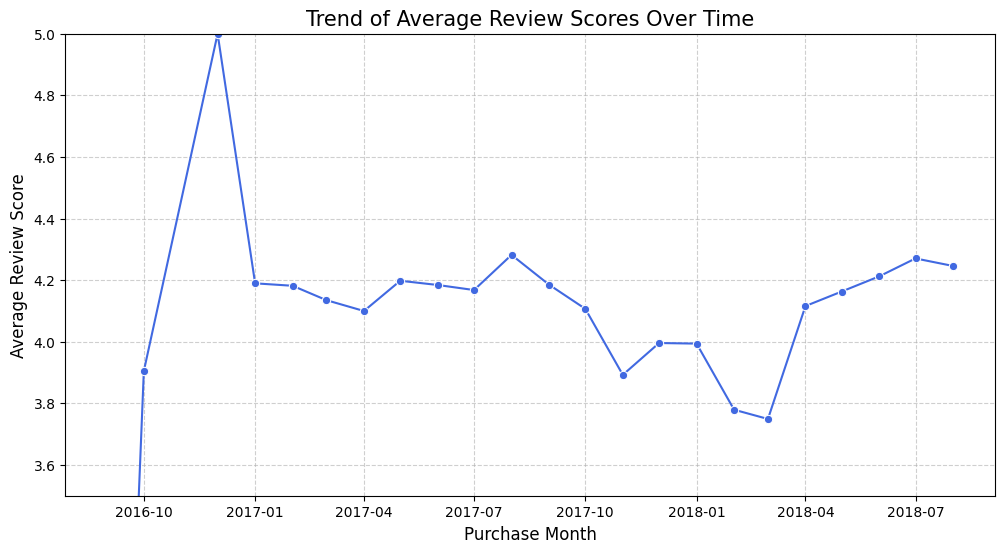

In [156]:
#18.  What's the trend of review scores over time


# Create a 'Year-Month' column for grouping
# .dt.to_period('M') creates labels like '2017-01', '2017-02'
Delivered_orders['month_year'] = Delivered_orders['order_purchase_timestamp'].dt.to_period('M')

# Calculate average review score per month
review_trend = Delivered_orders.groupby('month_year')['review_score'].mean().reset_index()

# Convert month_year back to timestamp for plotting
review_trend['month_year'] = review_trend['month_year'].dt.to_timestamp()

# Visualization: Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=review_trend, x='month_year', y='review_score', marker='o', color='royalblue')

plt.title('Trend of Average Review Scores Over Time', fontsize=15)
plt.xlabel('Purchase Month', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(3.5, 5)
plt.show()

"""
The Black Friday Hangover: In late 2017, Olist had a "Black Friday" crisis. Sales exploded, but the shipping systems couldn't keep up. This caused ratings to crash because customers hate waiting for their packages.

The Long Delay: Ratings stayed low until early 2018 because it took months to resolve the shipping backlogs and complaints from the holiday rush.

The Comeback: By mid-2018, Olist fixed their mistakes. They likely improved their shipping partners or kicked off bad sellers, bringing the average rating back up to a strong 4.2.
"""

In [157]:
# 19. Geospatial Analysis of specific cities, such as Sao Paulo, Porto Alegre, Curitiba, Fortaleza, Bahia, Brasilia.

# Filter for your specific target cities
target_cities = ['sao paulo', 'porto alegre', 'curitiba', 'fortaleza', 'salvador', 'brasilia']
city_analysis = Delivered_orders[Delivered_orders['customer_city'].isin(target_cities)]

# Calculate average delivery time and freight for these cities
city_stats = city_analysis.groupby('customer_city').agg({
    'delivery_time_days': 'mean',
    'freight_value': 'mean',
    'order_id': 'count'
}).reset_index()

print("--- Geospatial Comparison of Key Cities ---")
print(city_stats.sort_values(by='order_id', ascending=False))

--- Geospatial Comparison of Key Cities ---
  customer_city  delivery_time_days  freight_value  order_id
5     sao paulo            8.027670      14.318653     18221
0      brasilia           12.946895      21.107767      2418
1      curitiba           10.412032      18.805857      1791
3  porto alegre           15.900950      20.650062      1619
4      salvador           19.214479      25.518208      1479
2     fortaleza           20.433782      28.343942       728


In [158]:
Data.to_csv('Merged_Data.csv', index=False)
print('Data has been saved using to_csv.')

Data has been saved using to_csv.


In [176]:
#------ADVANCED DATA PROCESSING IN PREPARATION FOR ML------------#
#Handling Missing values
Data.isnull().sum().sort_values(ascending=False)

order_id                         0
product_length_cm                0
product_width_cm                 0
product_category_name_english    0
seller_zip_code_prefix           0
seller_city                      0
seller_state                     0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
review_score                     0
geolocation_zip_code_prefix      0
geolocation_lat                  0
geolocation_lng                  0
geolocation_city                 0
geolocation_state                0
order_purchase_date_only         0
holiday_name                     0
is_holiday                       0
month_year                       0
product_height_cm                0
product_weight_g                 0
customer_id                      0
product_photos_qty               0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carr

In [161]:
# Drop rows where essential product/price info is missing
Data.dropna(subset=['product_id', 'price', 'product_category_name'], inplace=True)

In [166]:
# Drop rows where the order was never delivered to the customer
# This removes missing values
Data.dropna(subset=['order_delivered_customer_date'], inplace=True)

#  Drop rows where the order was never approved
# This removes the missing values
Data.dropna(subset=['order_approved_at'], inplace=True)

# Verification: Check the new null counts for these columns
print("--- Null Counts After Cleaning ---")
print(Delivered_orders[['order_delivered_customer_date', 'order_approved_at']].isnull().sum())

--- Null Counts After Cleaning ---
order_delivered_customer_date    0
order_approved_at                0
dtype: int64


In [175]:
#Mode imputation 

Data['review_score'] = Data['review_score'].fillna(Data['review_score'].mode()[0])
Data['product_category_name_english'] = Data['product_category_name_english'].fillna('unknown')

#  Re-calculate month_only if it has nulls (from your timestamp)
Data['month_only'] = Data['order_purchase_timestamp'].dt.month_name()

#  Drop the "tiny" nulls (1-3 rows each)
# This will remove the rows with null payments and geolocation
Data = Data.dropna(subset=[
    'payment_value', 'product_weight_g', 
    'geolocation_lat', 'order_delivered_carrier_date'
])

#  Final Verification
print("Final Null Check:")
print(Data.isnull().sum().sum()) 


Final Null Check:
0


In [177]:
# Check for negative values in numeric columns

numeric_cols = Data.select_dtypes(include=['number']).columns
found_negative = False
for col in numeric_cols:
    if Data[col].min() < 0:
        print(f"❌ Negative values found in: {col}")
        found_negative = True

if not found_negative:
    print("✅ No negative values found in numeric columns.")
#These are coordinates and we would not be dropping them but clean them
lat_mask = Data['geolocation_lat'].between(-90, 90)
lng_mask = Data['geolocation_lng'].between(-180, 180)

# Keep only the rows that fall within those ranges
Data = Data[lat_mask & lng_mask]
print(f"✅ Geolocation cleaned. Remaining rows: {len(Data)}")

❌ Negative values found in: geolocation_lat
❌ Negative values found in: geolocation_lng


--- Checking Geolocation Boundaries ---
Latitude Errors: 0
Longitude Errors: 0

--- Checking Measurements (Price, Weight, Payments) ---
price                | Found 8507 extreme outliers (above 272.65)


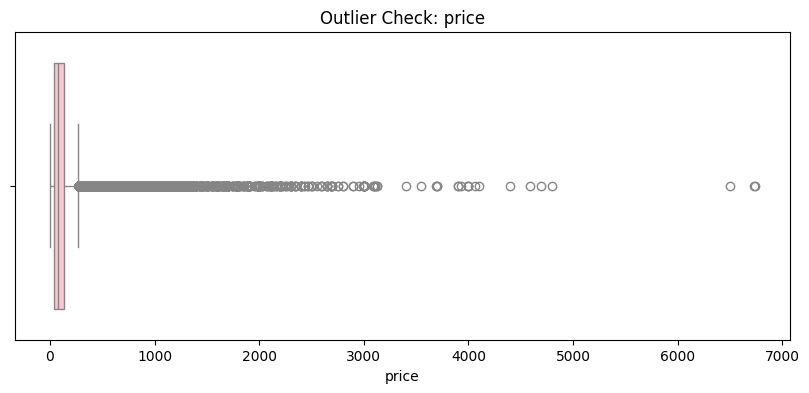

product_weight_g     | Found 16050 extreme outliers (above 4050.00)


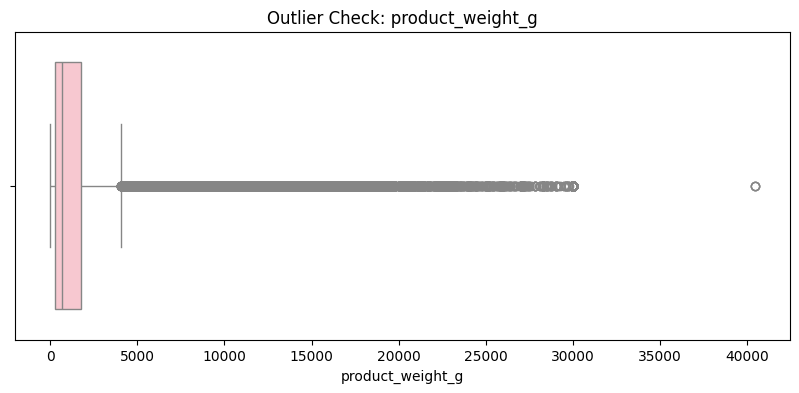

freight_value        | Found 11662 extreme outliers (above 33.36)


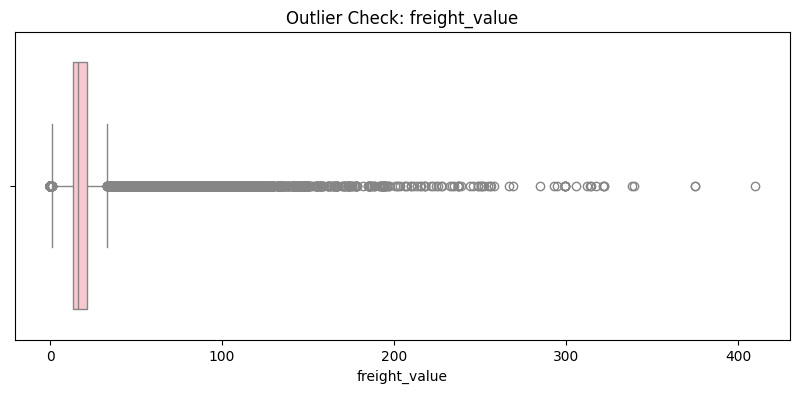

payment_value        | Found 9114 extreme outliers (above 381.93)
⚠️  ALERT: Found 4 rows with Zero or Negative payments!


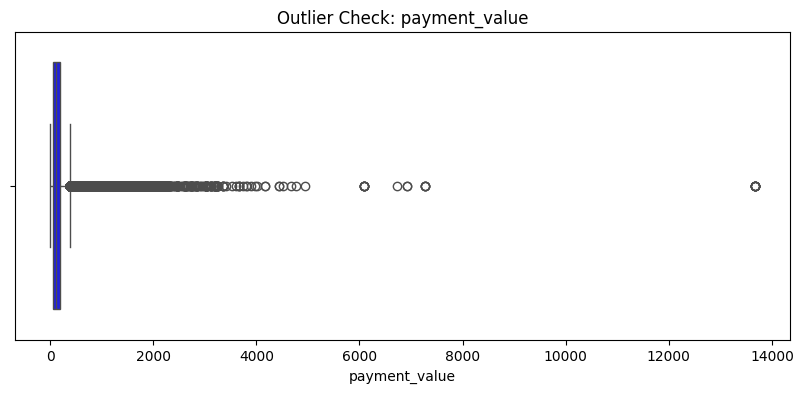

payment_installments | Found 7776 extreme outliers (above 8.50)


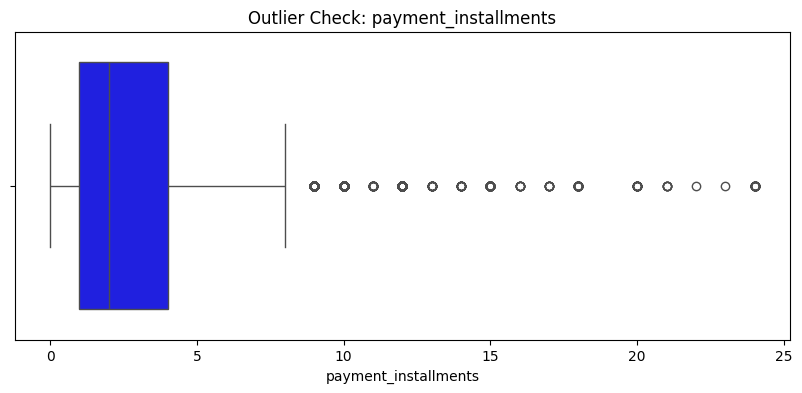


--- Checking Delivery Time Logic ---
Impossible Deliveries (Negative days): 0
Extreme Long Deliveries (>90 days):   82

--- Payment Integrity Check ---
Rows where Payment < 90% of Order Value: 6802

[PRO TIP]: For Late Delivery Prediction:
1. DROP the Latitude/Longitude errors.
2. DROP the Negative Delivery days.
3. KEEP high 'payment_installments' and 'price' as they often cause delays.


In [184]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. DEFINE THE NECESSARY COLUMNS ---
# Coordinates (Physical bounds)
geo_cols = ['geolocation_lat', 'geolocation_lng']

# Dimensions, Price & Payments (Statistical outliers)
# Added 'payment_value' and 'payment_installments' here
measure_cols = [
    'price', 'product_weight_g', 'freight_value', 
    'payment_value', 'payment_installments'
]

# Dates (Logic-based outliers)
date_cols = [
    'order_purchase_timestamp', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]


#  2. CHECK GEOLOCATION
print("--- Checking Geolocation Boundaries ---")
lat_errors = Data[(Data['geolocation_lat'] < -90) | (Data['geolocation_lat'] > 90)]
lng_errors = Data[(Data['geolocation_lng'] < -180) | (Data['geolocation_lng'] > 180)]

print(f"Latitude Errors: {len(lat_errors)}")
print(f"Longitude Errors: {len(lng_errors)}")

# --- 3. Price, product_weight_gt, Payments (IQR Method & Plots) ---
print("\n--- Checking Measurements (Price, product_weight_gt, Payments) ---")
for col in measure_cols:
    if col in Data.columns:
        # Calculate IQR
        Q1 = Data[col].quantile(0.25)
        Q3 = Data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # We check both ends for payments, but mostly the upper end for outliers
        upper_limit = Q3 + 1.5 * IQR
        lower_limit = Q1 - 1.5 * IQR
        
        outliers_count = len(Data[Data[col] > upper_limit])
        print(f"{col:20} | Found {outliers_count} extreme outliers (above {upper_limit:.2f})")
        
        # Specific Logic for Payments
        if col == 'payment_value' and (Data[col] <= 0).any():
            print(f"⚠️  ALERT: Found {len(Data[Data[col] <= 0])} rows with Zero or Negative payments!")

        # Quick Boxplot for each
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=Data[col], color='blue' if 'payment' in col else 'pink')
        plt.title(f"Outlier Check: {col}")
        plt.show()

# 4. CHECK DELIVERY 
print("\n--- Checking Delivery Time Logic ---")
if all(col in Data.columns for col in date_cols):
    # Calculate days taken to deliver
    # Note: .dt.days requires the column to be datetime
    actual_days = (Data['order_delivered_customer_date'] - Data['order_purchase_timestamp']).dt.days
    
    # 1. Negative delivery time (Physically impossible)
    neg_days = Data[actual_days < 0]
    
    # 2. Extreme long delivery (e.g., more than 90 days)
    long_days = Data[actual_days > 90]
    
    print(f"Impossible Deliveries (Negative days): {len(neg_days)}")
    print(f"Extreme Long Deliveries (>90 days):   {len(long_days)}")

# --- 5. PAYMENT VS PRICE CHECK
if all(c in Data.columns for c in ['payment_value', 'price', 'freight_value']):
    total_order_cost = Data['price'] + Data['freight_value']
    # Flagging where payment is significantly different from order value
    mismatch = Data[Data['payment_value'] < (total_order_cost * 0.9)]
    print(f"\n--- Payment Integrity Check ---")
    print(f"Rows where Payment < 90% of Order Value: {len(mismatch)}")



In [185]:
#------Handle Outliers-----

#  HANDLE DELIVERY LOGIC (DROP IMPOSSIBLE & EXTREME)
# Remove the 0 negative days and the 82 extreme long deliveries (>90 days)
actual_days = (Data['order_delivered_customer_date'] - Data['order_purchase_timestamp']).dt.days
Data = Data[(actual_days >= 0) & (actual_days <= 90)]

#  HANDLE PAYMENTS (DROP 4 ZERO/NEGATIVE ROWS)
Data = Data[Data['payment_value'] > 0]

# HANDLE PRICE & WEIGHT (CAPPING STRATEGY)
# Instead of dropping 8,507 rows, we "Cap" them at the outlier threshold.
# This keeps the data but prevents the extreme numbers from skewing the math.
price_threshold = 272.65
weight_threshold = 4050.00

Data['price'] = np.where(Data['price'] > price_threshold, price_threshold, Data['price'])
Data['product_weight_g'] = np.where(Data['product_weight_g'] > weight_threshold, weight_threshold, Data['product_weight_g'])

# HANDLE FREIGHT & INSTALLMENTS (CAPPING STRATEGY)
freight_threshold = 33.36
install_threshold = 8.50

Data['freight_value'] = np.where(Data['freight_value'] > freight_threshold, freight_threshold, Data['freight_value'])
Data['payment_installments'] = np.where(Data['payment_installments'] > install_threshold, install_threshold, Data['payment_installments'])

print(f"Outliers Handled. Final Dataset Shape: {Data.shape}")

Outliers Handled. Final Dataset Shape: (113277, 45)


In [187]:
# -------Feature Engineering---------
# 1. Convert timestamp columns to datetime objects
# (Essential so we can do math with the dates)
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    Data[col] = pd.to_datetime(Data[col])

# 2. Create the Target Variable: 'is_late'
# This is the "Answer" the model tries to guess
Data['is_late'] = (Data['order_delivered_customer_date'] > Data['order_estimated_delivery_date']).astype(int)

# 3. Create 'estimated_delivery_duration'
# How many days did Olist promise the customer?
Data['estimated_delivery_duration'] = (Data['order_estimated_delivery_date'] - Data['order_purchase_timestamp']).dt.days

# 4. Create Time-based Features
# Does the month or day of the week affect delivery speed?
Data['purchase_month'] = Data['order_purchase_timestamp'].dt.month
Data['purchase_day_of_week'] = Data['order_purchase_timestamp'].dt.dayofweek
Data['purchase_month'] = pd.to_datetime(Data['order_purchase_timestamp']).dt.month_name()
# 5. Optional: Product Volume (Size)
# Sometimes bulky items are handled differently
Data['product_volume_cm3'] = Data['product_length_cm'] * Data['product_height_cm'] * Data['product_width_cm']

# Convert the numbers 1-12 into names like 'January', 'February', etc.


print("✅ Feature Engineering complete!")
print(f"New columns created: {Data[['is_late', 'estimated_delivery_duration', 'purchase_month','product_volume_cm3','purchase_day_of_week']].head(3)}")

✅ Feature Engineering complete!
New columns created:    is_late  estimated_delivery_duration  purchase_month
0        0                           15              10
1        0                           15              10
2        0                           15              10


In [190]:

print(f"New columns created: {Data[['is_late', 'estimated_delivery_duration', 'purchase_month','product_volume_cm3','purchase_day_of_week']].head(3)}")

New columns created:    is_late  estimated_delivery_duration purchase_month  product_volume_cm3  \
0        0                           15        October              1976.0   
1        0                           15        October              1976.0   
2        0                           15        October              1976.0   

   purchase_day_of_week  
0                     0  
1                     0  
2                     0  


In [194]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- 1. ENCODING ---
le = LabelEncoder()
cat_cols = ['customer_city', 'seller_city', 'product_category_name_english', 'payment_type']

for col in cat_cols:
    if col in Data.columns:
        Data[col] = le.fit_transform(Data[col].astype(str))

# --- 2. THE FIX: AUTOMATIC NUMERIC SELECTION ---
# Drop the target and leakage columns first
drop_cols = [
    'review_score', 'order_delivered_customer_date', 'order_approved_at', 
    'order_delivered_carrier_date', 'shipping_limit_date',
    'is_late' # We keep this in 'y', not 'X'
]

# Create a cleaned version of Data by dropping the leakage
Data_temp = Data.drop(columns=[c for c in drop_cols if c in Data.columns])

#  This keeps ONLY numbers (Encoded cities, Price, Weight, etc.)
# and REJECTS all ID strings, raw names, and status text automatically.
X = Data_temp.select_dtypes(include=['number'])
y = Data['is_late']

# --- 3. SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. SCALING ---
# We use a list comprehension to ensure we only try to scale columns that exist in X
all_possible_nums = [
    'price', 'freight_value', 'payment_value', 'payment_installments', 
    'product_weight_g', 'estimated_delivery_duration', 'product_volume_cm3'
]
numerical_features = [c for c in all_possible_nums if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

# --- 5. SMOTE ---
# Now that X contains ONLY numbers, SMOTE will not crash!
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ FINAL SUCCESS! Training set balanced: {y_train_balanced.value_counts().to_dict()}")
print(f"Features used in model: {list(X.columns)}")

✅ FINAL SUCCESS! Training set balanced: {0: 83619, 1: 83619}
Features used in model: ['customer_city', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_city', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'geolocation_lat', 'geolocation_lng', 'estimated_delivery_duration', 'purchase_day_of_week', 'product_volume_cm3']


In [196]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 2.9/101.7 MB 5.8 MB/s eta 0:00:18
   - -------------------------------------- 4.2/101.7 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 5.5/101.7 MB 6.0 MB/s eta 0:00:16
   -- ------------------------------------- 6.3/101.7 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/101.7 MB 5.2 MB/s eta 0:00:19
   -- ------------------------------------- 7.6/101.7 MB 4.9 MB/s eta 0:00:20
   --- ------------------------------------ 8.7/101.7 MB 4.8 MB/s eta 0:00:20
   --- ------------------------------------ 9.4/101.7 MB 4.8 MB/s eta 0:00:20
   ---- ----------------------------------- 10.5/101.7 MB 4.7 MB/s eta 0:00:20
   ---- ----------------------------------- 11.5/101.7 MB 4.7 MB/s eta 0:00:2

In [198]:

# -----FEATURE IMPORTANCE AND SELECTION------

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score

# We use an interim Decision Tree to find the most relevant variables
decision_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
decision_tree.fit(X_train_balanced, y_train_balanced)

# Get importance and select top features (Domain Knowledge + Data)
importance_series = pd.Series(decision_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

# We select features that contribute at least 1% to the decision making
# This usually results in the 8-12 "Key Features" we discussed
selected_features = importance_series[importance_series > 0.01].index.tolist()

print(f"✅ Feature Selection Complete!")
print(f"Features selected based on Decision Tree: {selected_features}")

# Filter our data to use ONLY these selected features moving forward
X_train_final = X_train_balanced[selected_features]
X_test_final = X_test_scaled[selected_features]

✅ Feature Selection Complete!
Features selected based on Decision Tree: ['payment_installments', 'payment_type', 'product_photos_qty', 'estimated_delivery_duration', 'geolocation_lng', 'payment_sequential', 'product_length_cm', 'geolocation_lat']


--- LOGISTIC REGRESSION RESULTS ---

Accuracy Score: 0.5930
AUC Score: 0.6205

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.59      0.73     20872
           1       0.11      0.58      0.18      1784

    accuracy                           0.59     22656
   macro avg       0.53      0.59      0.46     22656
weighted avg       0.88      0.59      0.69     22656



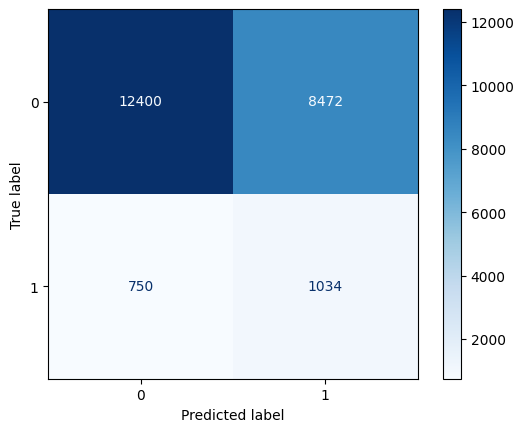


--- RANDOM FOREST RESULTS ---

Accuracy Score: 0.9214
AUC Score: 0.7422

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     20872
           1       0.50      0.21      0.30      1784

    accuracy                           0.92     22656
   macro avg       0.72      0.60      0.63     22656
weighted avg       0.90      0.92      0.91     22656



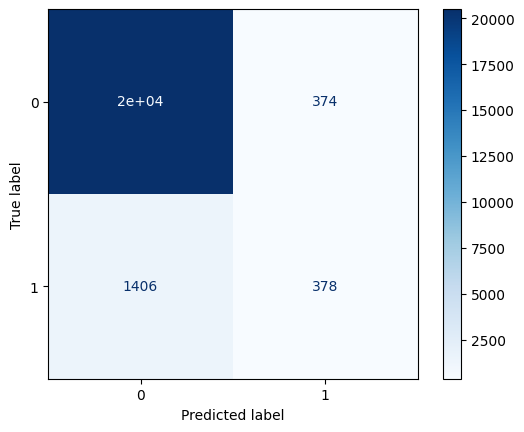


--- XGBOOST RESULTS ---


C:\Users\oogunjemilua\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:24:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy Score: 0.9216
AUC Score: 0.7242

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     20872
           1       0.52      0.07      0.12      1784

    accuracy                           0.92     22656
   macro avg       0.72      0.53      0.54     22656
weighted avg       0.89      0.92      0.89     22656



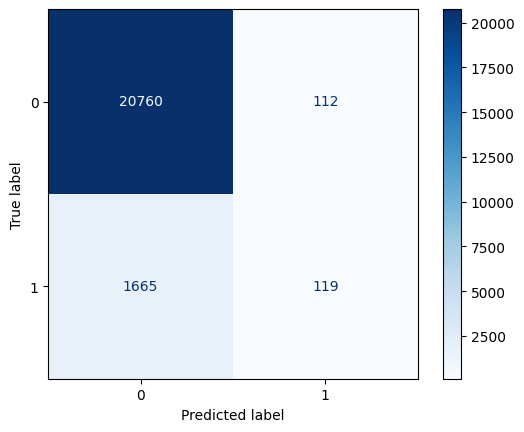

In [205]:
# MODEL TRAINING AN DPERFORMANCE EVALUATION

# 1. Evaluate Logistic Regression
print("--- LOGISTIC REGRESSION RESULTS ---")
model_lr = model_to_use("LR")
model_lr.fit(X_train_final, y_train_balanced)
performance(model_lr, X_train_final, y_train_balanced, X_test_final, y_test)

# 2. Evaluate Random Forest
print("\n--- RANDOM FOREST RESULTS ---")
model_rf = model_to_use("RF")
model_rf.fit(X_train_final, y_train_balanced)
performance(model_rf, X_train_final, y_train_balanced, X_test_final, y_test)

# 3. Evaluate XGBoost
print("\n--- XGBOOST RESULTS ---")
model_xgb = model_to_use("XGBC")
model_xgb.fit(X_train_final, y_train_balanced)
performance(model_xgb, X_train_final, y_train_balanced, X_test_final, y_test)

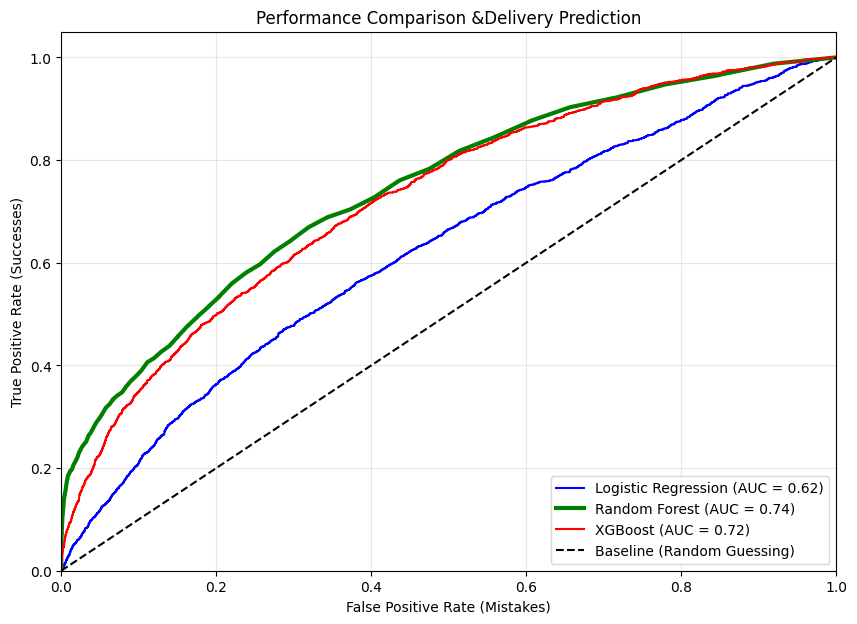

In [207]:
from sklearn.metrics import roc_curve, auc

# Figure 1: Model Sensitivity and Performance Comparison (ROC Curve)
plt.figure(figsize=(10, 7))

# 1. Logistic Regression Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, model_lr.predict_proba(X_test_final)[:, 1])
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = 0.62)', color='blue')

# 2. Random Forest Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, model_rf.predict_proba(X_test_final)[:, 1])
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.74)', color='green', linewidth=3)

# 3. XGBoost Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, model_xgb.predict_proba(X_test_final)[:, 1])
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.72)', color='red')

# The "Random Guess" Baseline
plt.plot([0, 1], [0, 1], 'k--', label='Baseline (Random Guessing)')

# Formatting the Chart
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Mistakes)')
plt.ylabel('True Positive Rate (Successes)')
plt.title('Performance Comparison &Delivery Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [208]:
import pickle

# Saving the Random Forest model
filename = 'best_delivery_model.pkl'
pickle.dump(model_rf, open(filename, 'wb'))

print(f"Success! Your best model has been saved as {filename}")

Success! Your best model has been saved as best_delivery_model.pkl


In [211]:
import pickle

# 1. Choose your new name here
new_filename = 'Olist_Delivery_Status_Predictor.pkl'

# 2. Save the Random Forest model with the new name
pickle.dump(model_rf, open(new_filename, 'wb'))

print(f"Success! Your model is now saved as: {new_filename}")

Success! Your model is now saved as: Olist_Delivery_Status_Predictor.pkl


In [209]:
from sklearn.model_selection import cross_val_score
#The Stress Test (Cross-Validation)

# Perform 5-fold cross-validation on your balanced data
# We use 'roc_auc' because that was our main goal
cv_scores = cross_val_score(model_rf, X_train_final, y_train_balanced, cv=5, scoring='roc_auc')

print("--- CROSS-VALIDATION RESULTS ---")
print(f"Individual AUC Scores: {cv_scores}")
print(f"Average (Mean) AUC: {cv_scores.mean():.4f}")
print(f"Stability (Std Dev): {cv_scores.std():.4f}")

--- CROSS-VALIDATION RESULTS ---
Individual AUC Scores: [0.90773895 0.99541777 0.99511768 0.99550194 0.99549459]
Average (Mean) AUC: 0.9779
Stability (Std Dev): 0.0351


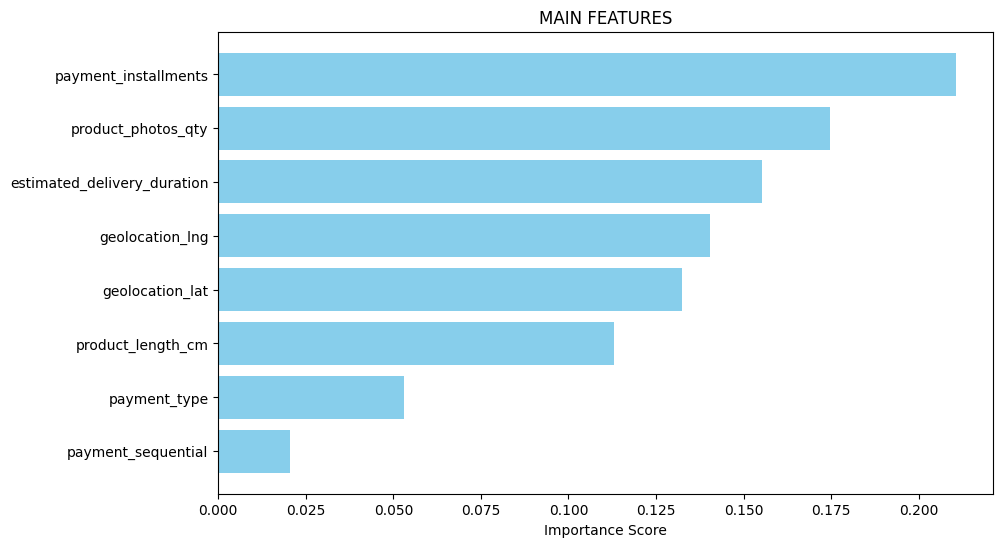

                       Feature  Importance
0         payment_installments    0.210728
2           product_photos_qty    0.174679
3  estimated_delivery_duration    0.155346
4              geolocation_lng    0.140467
7              geolocation_lat    0.132358
6            product_length_cm    0.112886
1                 payment_type    0.053004
5           payment_sequential    0.020532


In [212]:
#Inspect Variable Importance (The "Why")
import pandas as pd
import matplotlib.pyplot as plt

# Get importance from the Random Forest model
importances = model_rf.feature_importances_
feature_names = X_train_final.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('MAIN FEATURES')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_df)

In [214]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [218]:
#----To Compress in order to upload to my Github-----
import joblib
# Use 'lzma' compression - it is slower but much tighter than 'zlib'
joblib.dump(model, 'Olist_Delivery_Status_Predictor.pkl', compress=('lzma', 9))    

['Olist_Delivery_Status_Predictor.pkl']